# 02. Multi-Period DiD in the Callaway-Sant'Anna Style

This notebook is a self-contained introduction to staggered-adoption DiD with multiple time periods using a marketing example.

The setup follows the spirit of Callaway and Sant'Anna's group-time approach:
- markets adopt treatment in different periods,
- some markets are never treated,
- treatment effects can vary across cohorts and over exposure length, and
- the main building blocks are group-time average treatment effects, `ATT(g,t)`.

That is a better fit than collapsing everything into a single two-way fixed effects coefficient when treatment timing is staggered and effects are dynamic.

This notebook intentionally focuses on the simplest instructional version of that framework: never-treated markets as the comparison group, no covariate adjustment, and regression-based 2x2 estimates for each group-time cell.

## Learning Goals

By the end of this notebook, you should be able to:
- Explain the source of the shock in a staggered marketing rollout.
- State the identification assumptions behind multi-period DiD.
- Check whether treated and never-treated markets look similar before treatment.
- Assess parallel trends visually and with placebo pre-treatment estimates.
- Estimate group-time treatment effects `ATT(g,t)`.
- Cluster at the treatment-unit level to account for within-market correlation over time.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
rng = np.random.default_rng(2026)

## Marketing Setup And Source Of The Shock

Suppose a retailer rolls out a new AI-driven personalization engine for paid social and email across local markets. The vendor can only onboard a limited number of markets at a time because each market needs creative templates, inventory feeds, and QA signoff.

That generates a staggered rollout schedule:
- one wave starts in month 5,
- another starts in month 7,
- another starts in month 9, and
- a final set of markets stays untreated during the sample.

The **shock** is the first month the personalization engine turns on in a given market. The rollout timing is fixed in advance by operational capacity rather than by a sudden jump in demand in a particular market.

In [2]:
cohort_schedule = {5: 8, 7: 8, 9: 8, 0: 8}
n_months = 12

market_rows = []
for first_treat_month, count in cohort_schedule.items():
    for _ in range(count):
        market_rows.append(
            {
                "market_id": f"M{len(market_rows) + 1:02d}",
                "cohort": first_treat_month,
                "ever_treated": int(first_treat_month > 0),
                "population_index": rng.normal(100, 10),
                "digital_share": np.clip(rng.normal(0.42, 0.05), 0.25, 0.65),
                "historical_roas": rng.normal(4.0, 0.35),
                "market_fe": rng.normal(0, 6),
            }
        )

markets = pd.DataFrame(market_rows)
markets["cohort_label"] = markets["cohort"].map({0: "Never treated", 5: "Cohort 5", 7: "Cohort 7", 9: "Cohort 9"})

months = pd.DataFrame({"month": np.arange(1, n_months + 1)})
months["common_trend"] = np.array([-6, -4, -1, 1, 2, 4, 6, 7, 9, 11, 12, 14])
months["seasonality"] = np.array([-4, -2, -1, 0, 2, 3, 4, 6, 5, 7, 8, 6])

df = markets.assign(key=1).merge(months.assign(key=1), on="key").drop(columns="key")
df["treated"] = ((df["cohort"] > 0) & (df["month"] >= df["cohort"])).astype(int)
df["event_time"] = np.where(df["cohort"] > 0, df["month"] - df["cohort"], np.nan)

cohort_base_effect = df["cohort"].map({0: 0, 5: 12, 7: 10, 9: 9}).fillna(0)
dynamic_effect = np.where(
    df["treated"] == 1,
    cohort_base_effect + 2 * np.minimum(df["event_time"], 3),
    0,
)
df["treatment_effect"] = np.where(df["treated"] == 1, dynamic_effect, 0)

df["orders"] = (
    180
    + 0.70 * df["population_index"]
    + 45 * df["digital_share"]
    + 8 * df["historical_roas"]
    + df["market_fe"]
    + df["common_trend"]
    + df["seasonality"]
    + df["treatment_effect"]
    + rng.normal(0, 7, len(df))
).round(2)

df[["market_id", "cohort_label", "month", "treated", "orders"]].head()

,market_id,cohort_label,month,treated,orders
0,M01,Cohort 5,1,0,286.980
1,M01,Cohort 5,2,0,285.530
2,M01,Cohort 5,3,0,282.690
3,M01,Cohort 5,4,0,292.240
4,M01,Cohort 5,5,1,320.680


## Identification Assumptions

In this multi-period setting, the core assumptions are:
- **Group-specific parallel trends:** absent treatment, each treated cohort would have evolved like the never-treated markets.
- **No anticipation:** markets do not respond before their rollout month.
- **No spillovers:** treatment in one market does not change outcomes in never-treated markets.
- **Stable composition and measurement:** the set of markets and the way orders are measured do not change over time.
- **Rollout timing is as-good-as predetermined:** adoption month is driven by onboarding capacity, not by idiosyncratic demand shocks.

With staggered timing and heterogeneous effects, we focus on `ATT(g,t)` rather than a single pooled treatment coefficient.

## 1. Are Treated And Never-Treated Markets Similar Before Any Rollout?

A first diagnostic is to compare baseline market characteristics before the first treated cohort turns on. Similarity does not prove identification, but strong imbalances would be a warning sign.

In [3]:
first_treated_month = min(month for month in cohort_schedule if month > 0)
pre_rollout_market = (
    df[df["month"] < first_treated_month]
    .groupby("market_id", as_index=False)
    .agg(pre_rollout_orders=("orders", "mean"))
)

market_level = markets.merge(pre_rollout_market, on="market_id")

covariate_labels = {
    "population_index": "Population index",
    "digital_share": "Digital share",
    "historical_roas": "Historical ROAS",
    "pre_rollout_orders": "Average pre-rollout orders",
}

balance_rows = []
for covariate, label in covariate_labels.items():
    treated_values = market_level.loc[market_level["ever_treated"] == 1, covariate]
    control_values = market_level.loc[market_level["ever_treated"] == 0, covariate]
    pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
    balance_model = smf.ols(f"{covariate} ~ ever_treated", data=market_level).fit(cov_type="HC1")
    balance_rows.append(
        {
            "variable": label,
            "treated_mean": treated_values.mean(),
            "never_treated_mean": control_values.mean(),
            "difference": treated_values.mean() - control_values.mean(),
            "std_diff": (treated_values.mean() - control_values.mean()) / pooled_sd,
            "p_value": balance_model.pvalues["ever_treated"],
        }
    )

balance_table = pd.DataFrame(balance_rows)
balance_table.round(3)

,variable,treated_mean,never_treated_mean,difference,std_diff,p_value
0,Population index,99.579,100.494,-0.914,-0.082,0.839
1,Digital share,0.430,0.437,-0.007,-0.152,0.677
2,Historical ROAS,3.986,3.978,0.009,0.027,0.942
3,Average pre-rollout orders,297.673,300.173,-2.500,-0.207,0.597


In [4]:
market_level.groupby("cohort_label")[["population_index", "digital_share", "historical_roas", "pre_rollout_orders"]].mean().round(3)

,population_index,digital_share,historical_roas,pre_rollout_orders
cohort_label,,,,
Cohort 5,97.555,0.438,3.844,296.105
Cohort 7,102.166,0.446,4.108,302.501
Cohort 9,99.017,0.405,4.007,294.412
Never treated,100.494,0.437,3.978,300.173


## 2. Illustrate The Calendar-Time Trajectory

Before estimating `ATT(g,t)`, it helps to plot average outcomes by rollout cohort over calendar time. The idea is to see whether cohorts move similarly before their adoption dates and then diverge after treatment starts.

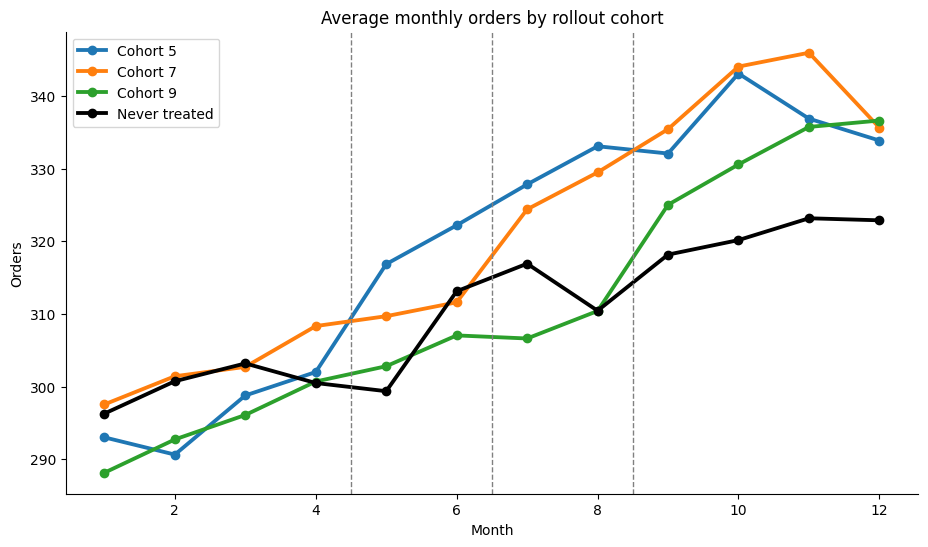

In [5]:
calendar_means = df.groupby(["month", "cohort_label"], as_index=False)["orders"].mean()
color_map = {
    "Never treated": "black",
    "Cohort 5": "tab:blue",
    "Cohort 7": "tab:orange",
    "Cohort 9": "tab:green",
}

fig, ax = plt.subplots(figsize=(11, 6))
for cohort_label, cohort_df in calendar_means.groupby("cohort_label"):
    ax.plot(
        cohort_df["month"],
        cohort_df["orders"],
        color=color_map[cohort_label],
        marker="o",
        linewidth=2.75,
        label=cohort_label,
    )

for adoption_month in [5, 7, 9]:
    ax.axvline(adoption_month - 0.5, color="gray", linestyle="--", linewidth=1)

ax.set_title("Average monthly orders by rollout cohort")
ax.set_xlabel("Month")
ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=True)
plt.show()

A more focused pre-period view uses only months before the first rollout. If the lines look similar there, that supports the parallel-trends story.

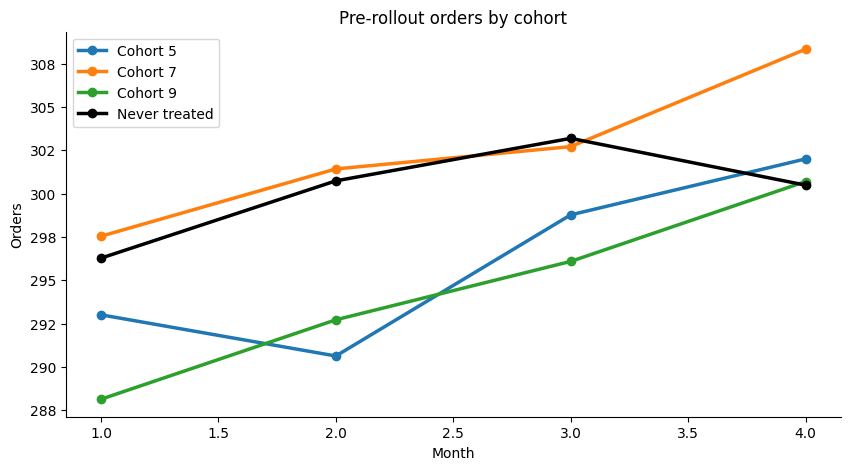

In [6]:
pre_calendar_means = calendar_means[calendar_means["month"] < first_treated_month]

fig, ax = plt.subplots()
for cohort_label, cohort_df in pre_calendar_means.groupby("cohort_label"):
    ax.plot(
        cohort_df["month"],
        cohort_df["orders"],
        color=color_map[cohort_label],
        marker="o",
        linewidth=2.5,
        label=cohort_label,
    )

ax.set_title("Pre-rollout orders by cohort")
ax.set_xlabel("Month")
ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=True)
plt.show()

## 3. Estimate Group-Time Effects `ATT(g,t)`

Callaway-Sant'Anna style DiD is built from cohort-time effects. For a cohort first treated in period `g`, the parameter `ATT(g,t)` is the treatment effect for that cohort in period `t`.

In this notebook, we estimate each `ATT(g,t)` by comparing:
- the change for cohort `g` between period `g-1` and period `t`, and
- the same change for never-treated markets over those same two periods.

Using `t < g` gives placebo estimates that should be close to zero if pre-trends are parallel.

The full paper also studies identification under covariate-adjusted parallel trends and discusses outcome-regression, inverse-probability-weighting, and doubly robust estimators. Here we isolate the group-time `ATT(g,t)` logic in the cleanest possible case.

In [7]:
treated_cohorts = sorted(markets.loc[markets["ever_treated"] == 1, "cohort"].unique())
cohort_sizes = markets.loc[markets["cohort"] > 0].groupby("cohort").size().to_dict()

def estimate_att_gt(data, cohort, time_period):
    base_period = cohort - 1
    if time_period == base_period:
        return None

    subset = data.loc[
        ((data["cohort"] == cohort) | (data["cohort"] == 0))
        & (data["month"].isin([base_period, time_period]))
    ].copy()

    subset["group_time_indicator"] = (
        (subset["cohort"] == cohort) & (subset["month"] == time_period)
    ).astype(int)

    model = smf.ols(
        "orders ~ group_time_indicator + C(market_id) + C(month)",
        data=subset,
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": subset["market_id"]},
    )

    estimate = model.params["group_time_indicator"]
    std_error = model.bse["group_time_indicator"]

    return {
        "cohort": cohort,
        "month": time_period,
        "event_time": time_period - cohort,
        "post_period": int(time_period >= cohort),
        "att_gt": estimate,
        "std_error": std_error,
        "ci_low": estimate - 1.96 * std_error,
        "ci_high": estimate + 1.96 * std_error,
        "weight": cohort_sizes[cohort],
    }

att_gt_results = pd.DataFrame(
    result
    for cohort in treated_cohorts
    for month in range(1, n_months + 1)
    for result in [estimate_att_gt(df, cohort, month)]
    if result is not None
)

att_gt_results.head()

,cohort,month,event_time,post_period,att_gt,std_error,ci_low,ci_high,weight
0,5,1,-4,0,-4.782,7.565,-19.609,10.044,8
1,5,2,-3,0,-11.615,7.378,-26.076,2.846,8
2,5,3,-2,0,-5.925,6.710,-19.077,7.227,8
3,5,5,0,1,15.984,6.116,3.996,27.971,8
4,5,6,1,1,7.567,4.973,-2.179,17.314,8


The placebo estimates below correspond to `t < g`. These should be centered near zero if the treated cohorts and never-treated markets follow similar trends before rollout.

In [8]:
placebo_table = (
    att_gt_results[att_gt_results["post_period"] == 0]
    .pivot(index="cohort", columns="event_time", values="att_gt")
    .sort_index(axis=1)
)
placebo_table.round(3)

event_time,-8,-7,-6,-5,-4,-3,-2
cohort,,,,,,,
5,NaN,NaN,NaN,NaN,-4.782,-11.615,-5.925
7,NaN,NaN,2.785,2.208,1.045,9.361,11.846
9,-8.102,-7.979,-7.061,0.244,3.474,-6.042,-10.262


To summarize the full multi-period pattern, aggregate the cohort-time effects by event time. Negative event times are placebo leads, while nonnegative event times are post-treatment effects.

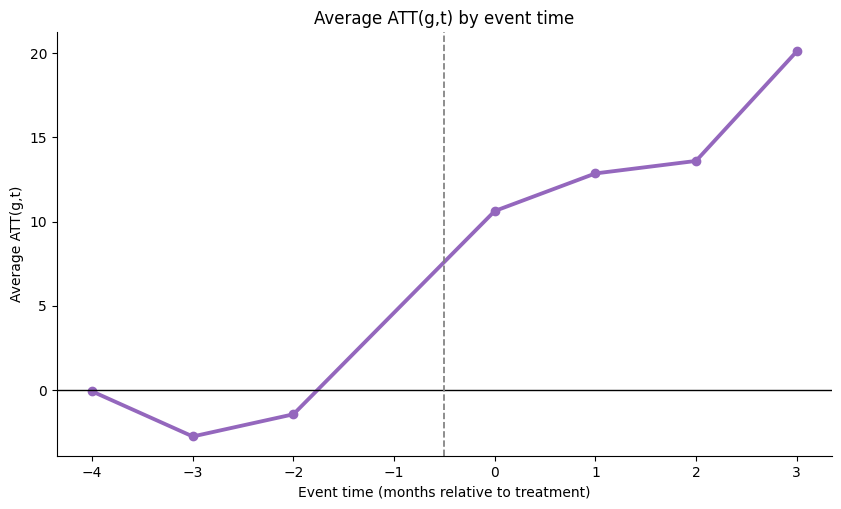

In [9]:
event_rows = []
for event_time, event_df in att_gt_results.groupby("event_time"):
    event_rows.append(
        {
            "event_time": event_time,
            "avg_att": np.average(event_df["att_gt"], weights=event_df["weight"]),
            "n_cohorts": event_df["cohort"].nunique(),
        }
    )

event_study = pd.DataFrame(event_rows).sort_values("event_time")
event_plot = event_study[(event_study["event_time"] >= -4) & (event_study["event_time"] <= 3)]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(event_plot["event_time"], event_plot["avg_att"], marker="o", linewidth=2.75, color="tab:purple")
ax.axhline(0, color="black", linewidth=1)
ax.axvline(-0.5, color="gray", linestyle="--", linewidth=1.25)
ax.set_title("Average ATT(g,t) by event time")
ax.set_xlabel("Event time (months relative to treatment)")
ax.set_ylabel("Average ATT(g,t)")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
plt.show()

## 4. Apply Multi-Period DiD And Summarize Post-Treatment Effects

Now focus on the post-treatment `ATT(g,t)` estimates. These are the causal effects for each rollout cohort in each post period relative to never-treated markets.

In [10]:
post_att = att_gt_results[att_gt_results["post_period"] == 1].copy()
post_table = (
    post_att
    .pivot(index="cohort", columns="event_time", values="att_gt")
    .sort_index(axis=1)
)
post_table.round(3)

event_time,0,1,2,3,4,5,6,7
cohort,,,,,,,,
5,15.984,7.567,9.403,21.130,12.402,21.418,12.202,9.469
7,9.003,20.562,18.792,25.407,24.311,14.271,NaN,NaN
9,6.893,10.448,12.610,13.773,NaN,NaN,NaN,NaN


In [11]:
overall_att = np.average(post_att["att_gt"], weights=post_att["weight"])

true_gt = (
    df[df["treated"] == 1]
    .groupby(["cohort", "month"], as_index=False)["treatment_effect"]
    .mean()
)
true_gt["weight"] = true_gt["cohort"].map(cohort_sizes)
overall_true_att = np.average(true_gt["treatment_effect"], weights=true_gt["weight"])

print(f"Average post-treatment ATT across cohort-time cells: {overall_att:.2f} additional orders per market-month")
print(f"Average true simulated effect across cohort-time cells: {overall_true_att:.2f} additional orders per market-month")

Average post-treatment ATT across cohort-time cells: 14.76 additional orders per market-month
Average true simulated effect across cohort-time cells: 14.67 additional orders per market-month


## Why We Cluster At The Market Level

Each `ATT(g,t)` regression uses repeated observations for the same markets across time. That means the error term can be correlated within a market over months.

To account for that serial dependence, every group-time DiD regression above clusters the standard errors at `market_id`, which is the treatment-unit level in this example.

## Takeaways

- The shock is the staggered market-by-market rollout of the personalization engine.
- Identification comes from parallel untreated trends between each treated cohort and the never-treated markets, plus no anticipation and no spillovers.
- Baseline similarity checks and pre-period trajectories support the design.
- Placebo `ATT(g,t)` estimates for `t < g` provide an additional parallel-trends diagnostic.
- The main estimands are group-time treatment effects rather than a single pooled DiD coefficient.
- Clustered inference belongs at the market level because treatment and serial correlation both operate there.

In [12]:
summary = pd.Series({
    "First treated month": first_treated_month,
    "Number of treated cohorts": len(treated_cohorts),
    "Average ATT(g,t)": round(overall_att, 2),
    "Average true effect": round(overall_true_att, 2),
    "Markets": df["market_id"].nunique(),
})
summary

First treated month          5.000
Number of treated cohorts    3.000
Average ATT(g,t)            14.760
Average true effect         14.670
Markets                     32.000
dtype: float64